# **Predicting Waze User Churn**
**Stage 5 -  Machine learning model**

**Situation:** We're close to completing our user churn project. Previously, we completed a project proposal, used Python to explore and analyze Waze's user data, created data visualizations, and conducted a hypothesis test. Most recently, we built a binomial logistic regression model based on multiple variables.

Now, we want to **build a machine learning model to predict user churn**. To get the best results, we decided to build and test two tree-based models: random forest and XGBoost.

Our work will help leadership make informed business decisions to prevent user churn, improve user retention, and grow Waze's business.

# **Building a machine learning model**

In this stage, let's practice using tree-based modeling techniques to predict on a binary target class.
<br/>

**The purpose** of this model is to find factors that drive user churn.

**The goal** of this model is to predict whether or not a Waze user is retained or churned.
<br/>

*This stage has three parts:*

**Part 1:** Ethical considerations
* Considering the ethical implications of the request

**Part 2:** Feature engineering

* Performing feature selection, extraction, and transformation to prepare our data for modeling

**Part 3:** Modeling

* Building our models, evaluate them, and advise on next steps.

# **PACE stages**


Throughout these project notebooks, we're going to use the problem-solving framework PACE. The following notebook components are labeled with their respective PACE stages: Plan, Analyze, Construct, and Execute.

## **PACE: Plan**

1. We've been asked to develop a machine learning model that can predict wethere a user will churn or not.
2. There is no ethical problems with the model. Two type of errors may occur, false positve my cause the company money and effort trying to prevent user from churning while he is acctualy wasn't planning for churn. false negative error may cause the company to lose the user.
3. While these errors may occur, the prediction process can prevent much more of such cases if the model was better than random classifier.

### **Part 1. Imports and data loading**

Let's import the packages and libraries we need to build and evaluate our random forest and XGBoost classification models.

In [ ]:
# Importing packages for data manipulation
import pandas as pd
import numpy as np

# Importing packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Setting option to see all of the columns, preventing Jupyter from redacting them
pd.set_option('display.max_columns', None)

# Importing packages for data modeling
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics
from sklearn.model_selection import GridSearchCV, train_test_split

# Importing the function that helps plot feature importance
from xgboost import plot_importance

# Saving our models once we fit them
import pickle

Now let's read in our dataset as `df0` and inspect the first five rows.

In [ ]:
# Importing dataset
df0 = pd.read_csv('waze_dataset.csv')

In [ ]:
# Inspecting the first five rows
df0.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


## **PACE: Analyze**

### **Part 2. Feature engineering**

We have already prepared much of this data and performed exploratory data analysis (EDA) in previous stages. We know that some features had stronger correlations with churn than others, and we also created some features that may be useful.

In this part of our project, we'll engineer these features and some new features to use for our modeling.

To begin, we'll create a copy of `df0` to preserve our original dataframe, calling our copy `df`.

In [ ]:
# Copying the df0 dataframe
df = df0.copy()

Let's call `info()` on our new dataframe so we can easily reference our existing columns.

In [ ]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


#### **`km_per_driving_day`**

1. Let's create a feature representing the mean number of kilometers driven on each driving day in the last month for each user. We'll add this feature as a column to our `df`.

2. Then, we will get descriptive statistics for this new feature.

In [ ]:
# 1. Creating `km_per_driving_day` feature
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# 2. Getting descriptive stats
df['km_per_driving_day'].describe()

count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

We notice that some values are infinite. This is the result of there being values of zero in our `driving_days` column. Pandas imputes a value of infinity in the corresponding rows of our new column because division by zero is undefined.

1. We'll convert these values from infinity to zero. We can use `np.inf` to refer to our value of infinity.

2. Then we'll call `describe()` on our `km_per_driving_day` column to verify that our fix worked.

In [ ]:
# 1. Converting infinite values to zero
df.loc[df['km_per_driving_day'] == np.inf, 'km_per_driving_day' ] = 0

# 2. Confirming that it worked
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,1246.901868
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667


#### **`percent_sessions_in_last_month`**

1. We'll create a new column `percent_sessions_in_last_month` that represents the percentage of each user's total sessions that were logged in their last month of use.

2. Then, we'll get descriptive statistics for this new feature.

In [ ]:
# 1. Creating `percent_sessions_in_last_month` feature
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

# 2. Getting descriptive stats
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,percent_sessions_in_last_month
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,0.953670
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,1246.901868,0.406856
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,0.841186
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,0.724968
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,0.499266


#### **`professional_driver`**

Let's create a new, binary feature called `professional_driver` that is a 1 for users who had 60 or more drives <u>**and**</u> drove on 15+ days in the last month.

 Our objective is to create a new feature that separates professional drivers from other drivers. In this scenario, we use domain knowledge and intuition to determine these deciding thresholds, but ultimately they are arbitrary.

To create this column, we'll use the [`np.where()`](https://numpy.org/doc/stable/reference/generated/numpy.where.html) function. This function accepts as arguments:
1. Our condition
2. What we want to return when the condition is true
3. What we want to return when the condition is false

In [ ]:
# Creating `professional_driver` feature
df['professional_driver'] = np.where((df['drives']>=60)&(df['driving_days']>15),1,0)

#### **`total_sessions_per_day`**

Now, we're going to create a new column that represents the mean number of sessions per day _since onboarding_.

In [ ]:
# Creating `total_sessions_per_day` feature
df['total_sessions_per_day'] = df['total_sessions'] / df['n_days_after_onboarding']

As we did with other features, we'll get descriptive statistics for our new feature.

In [ ]:
# Getting descriptive stats
df['total_sessions_per_day'].describe()

count    14999.000000
mean         0.338698
std          1.314333
min          0.000298
25%          0.051037
50%          0.100775
75%          0.216269
max         39.763874
Name: total_sessions_per_day, dtype: float64

#### **`km_per_hour`**

Let's create a column representing our mean kilometers per hour driven in the last month.

In [ ]:
# Creating `km_per_hour` feature
df['km_per_hour'] = df['driven_km_drives']/df['duration_minutes_drives'] * 60

#### **`km_per_drive`**

We'll create a column representing the mean number of kilometers per drive made in the last month for each of our users. Then, we'll print the descriptive statistics for our feature.

In [ ]:
# Creating `km_per_drive` feature
df['km_per_drive'] = df['driven_km_drives'] / df['drives']

This feature has infinite values too. Let's convert the infinite values to zero, and then confirm that our code worked.

In [ ]:
# 1. Converting infinite values to zero
df.loc[df['km_per_drive']==np.inf, 'km_per_drive']= 0

# 2. Confirming that it worked
df['km_per_drive'].describe()

count    14999.000000
mean       232.817946
std        620.622351
min          0.000000
25%         32.424301
50%         72.854343
75%        179.347527
max      15777.426560
Name: km_per_drive, dtype: float64

#### **`percent_of_sessions_to_favorite`**

Finally, we'll create a new column that represents the percentage of total sessions that were used to navigate to one of the users' favorite places. Then, we'll print our descriptive statistics for this new column.

This is a proxy representation for our percent of overall drives that are to a favorite place. Since total drives since onboarding are not contained in our dataset, we use total sessions as a reasonable approximation.

Our expectation is that people whose drives to non-favorite places make up a higher percentage of their total drives might be less likely to churn, since they're making more drives to less familiar places.

In [ ]:
# Creating `percent_of_sessions_to_favorite` feature
df['percent_of_sessions_to_favorite'] = (df['total_navigations_fav1']+df['total_navigations_fav2'])/df['total_sessions']

# Getting descriptive stats
df['percent_of_sessions_to_favorite'].describe()

count    14999.000000
mean         1.665439
std          8.865666
min          0.000000
25%          0.203471
50%          0.649818
75%          1.638526
max        777.563629
Name: percent_of_sessions_to_favorite, dtype: float64

### **Part 3. Drop missing values**

Because we know from our previous EDA that there is no evidence of a non-random cause of the 700 missing values in our `label` column, and because these observations comprise less than 5% of our data, we'll use the `dropna()` method to drop the rows that are missing this data.

In [ ]:
# Dropping rows with missing values
df = df.dropna(axis=0)

### **Part 4. Outliers**

We know from our previous EDA that many of these columns have outliers. However, tree-based models are resilient to outliers, so we do not need to make any imputations.

### **Part 5. Variable encoding**

#### **Dummying features**

In order to use `device` as an X variable, we need to convert it to binary, since this variable is categorical.

In cases where our data contains many categorical variables, we can use pandas' built-in [`pd.get_dummies()`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html), or we can use scikit-learn's [`OneHotEncoder()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) function.

 Each possible category of each feature will result in a feature for our model, which could lead to an inadequate ratio of features to observations and/or difficulty understanding our model's predictions.

Because our dataset only has one remaining categorical feature (`device`), we don't need to use those special functions. We'll just implement the transformation directly.

We'll create a new, binary column called `device2` that encodes our user devices as follows:

* `Android` -> `0`
* `iPhone` -> `1`

In [ ]:
# Creating new `device2` variable
df['device2'] = df['device'].replace({'Android':0, 'iPhone':1})
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,percent_sessions_in_last_month,professional_driver,total_sessions_per_day,km_per_hour,km_per_drive,percent_of_sessions_to_favorite,device2
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,0.953670,1,0.130381,79.430298,11.632058,0.700931,0
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,1246.901868,0.406856,0,0.266854,260.389902,128.186173,0.253903,1
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,0.841186,0,0.051121,113.953460,32.201567,0.000000,0
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,0.724968,0,4.505948,93.351141,22.839778,4.867640,1
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,0.499266,1,0.107713,194.342970,58.091206,1.016363,0


#### **Target encoding**

Our target variable is also categorical, since a user is labeled as either "churned" or "retained." We need to change the data type of the `label` column to be binary to train our models.

We'll assign a `0` for all `retained` users.

We'll assign a `1` for all `churned` users.

We'll save this variable as `label2` so as not to overwrite our original `label` variable.

 There are many ways to do this. We'll use `np.where()` just as we did earlier in our notebook.

In [ ]:
# Creating binary `label2` column
df['label2'] = np.where(df['label']=='churned',1,0)

### **Part 6. Feature selection**

Our tree-based models can handle multicollinearity, so the only feature we need to cut is `ID`, since it doesn't contain any information relevant to churn.

Note, however, that we won't use `device` simply because it's a copy of our `device2` variable.

Let's drop `ID` from our `df` dataframe.

In [ ]:
# Dropping `ID` column
df = df.drop('ID', axis=1)

### **Part 7. Evaluation metric**

Before we begin modeling, we'll decide on our evaluation metric. This will depend on the class balance of our target variable and our specific use case.

First, we'll examine the class balance of our target variable.

In [ ]:
# Getting class balance of 'label' col
df.label.value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

Approximately 18% of the users in our dataset churned. This is an unbalanced dataset, but not extremely so. We can model it without any class rebalancing.

Now, we'll consider which evaluation metric is best. We remember that accuracy might not be the best gauge of performance because our model can have high accuracy on an imbalanced dataset and still fail to predict our minority class.

It was already determined that the risks involved in making a false positive prediction are minimal for us. No one stands to get hurt, lose money, or suffer any other significant consequence if they are predicted to churn. Therefore, we'll select our model based on the recall score.

## **PACE: Construct**

### **Part 8. Modeling workflow and model selection process**

Our final modeling dataset contains 14,299 samples. This is towards the lower end of what we consider sufficient to conduct a robust model selection process, but still doable.

1. We will split our data into train/validation/test sets (60/20/20)

Note that, when deciding our split ratio and whether or not to use a validation set to select our champion model, we consider both how many samples will be in each data partition, and how many examples of the minority class each would therefore contain. In our case, a 60/20/20 split will result in ∼2,860 samples in our validation set and the same number in our test set, of which ∼18%&mdash;or 515 samples&mdash;represent users who churn.
2. We will fit our models and tune hyperparameters on our training set
3. We will perform our final model selection on the validation set
4. We will assess our champion model's performance on the test set

### **Part 9. Split our data**

Now we're ready to model. Our remaining step is to split our data into features/target variable and training/validation/test sets.

1. Let's define our variable `X` that isolates our features, making sure not to use `device`.

2. We'll define our variable `y` that isolates our target variable (`label2`).

3. We'll split our data 80/20 into an interim training set and a test set. We'll stratify our splits and set our random state to 42.

4. We're going to split our interim training set 75/25 into a training set and a validation set, yielding our final ratio of 60/20/20 for training/validation/test sets. Again, we'll stratify our splits and set our random state.

In [ ]:
# 1. Isolating X variables
x= df.drop(columns=['label','label2','device'], axis=1)

# 2. Isolating y variable
y = df['label2']

# 3. Splitting into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x,y,stratify = y, test_size=0.2, random_state=42)

# 4. Splitting into train and validate sets
x_tr, x_val, y_tr, y_val = train_test_split(x_train,y_train,stratify = y_train, test_size=0.25, random_state=42)

Let's verify the number of samples in our partitioned data.

In [ ]:
print(x_tr.shape,x_train.shape, x_val.shape, x_test.shape, y_tr.shape,y_train.shape, y_val.shape, y_test.shape)
x_tr.head()

(8579, 18) (11439, 18) (2860, 18) (2860, 18) (8579,) (11439,) (2860,) (2860,)


,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,percent_sessions_in_last_month,professional_driver,total_sessions_per_day,km_per_hour,km_per_drive,percent_of_sessions_to_favorite,device2
627,354,334,387.952131,1702,102,69,2675.597422,1769.200501,19,18,148.644301,0.912484,1,0.227939,90.739204,8.010771,0.440776,1
8588,61,49,186.438384,3435,29,37,2983.491114,1876.611394,27,23,129.717005,0.327186,0,0.054276,95.389737,60.887574,0.354004,0
3202,199,160,326.029353,1145,0,0,3723.097732,2225.499258,8,8,465.387217,0.610374,0,0.284742,100.375618,23.269361,0.000000,1
12449,21,21,57.436499,2808,0,1,1622.526652,432.967910,22,15,108.168443,0.365621,0,0.020455,224.847147,77.263174,0.017411,1
7185,105,105,144.822673,3030,17,84,10559.209360,5463.480168,31,30,351.973645,0.725025,1,0.047796,115.961355,100.563899,0.697405,1


This aligns with our expectations.

### **Part 10. Modeling**

#### **Random forest**

We're going to begin by using `GridSearchCV` to tune our random forest model.

1. Let's instantiate our random forest classifier `rf` and set our random state.

2. We'll create our dictionary `cv_params` of hyperparameters and our corresponding values to tune:
 - `max_depth`
 - `max_features`
 - `max_samples`
 - `min_samples_leaf`
 - `min_samples_split`
 - `n_estimators`

3. We'll define our list `scoring` of scoring metrics for our GridSearch to capture (precision, recall, F1 score, and accuracy).

4. We'll instantiate our `GridSearchCV` object `rf_cv`. We will pass to it:
 - estimator=`rf`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of cross-validation folds we want (`cv=_`)
 - refit: indicate our evaluation metric of choice (`refit=_`)

 We'll set `refit` to `'recall'`.

 If our model fitting takes too long, we can try reducing the number of options to search over in our grid search.

In [ ]:
# 1. Instantiating the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Creating a dictionary of hyperparameters to tune
cv_params = {'n_estimators':[75,100,150],
    'max_depth':[4,5,6],
    'min_samples_split':[15,20,30],
    'min_samples_leaf':[2,3,5]}

# 3. Defining a list of scoring metrics to capture
scoring = ['accuracy','precision', 'recall', 'f1']

# 4. Instantiating the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5,refit='recall')

Now we'll fit our model to our training data.

In [ ]:
rf_cv.fit(x_tr, y_tr)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [4, 5, 6], 'min_samples_leaf': [2, 3, 5],
                         'min_samples_split': [15, 20, 30],
                         'n_estimators': [75, 100, 150]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

We'll examine our best average score across all our validation folds.

In [ ]:
# Examining best score
rf_cv.best_score_

0.035470232959447796

We'll examine our best combination of hyperparameters.

In [ ]:
# Examining best hyperparameter combo
rf_cv.best_params_

{'max_depth': 6,
 'min_samples_leaf': 5,
 'min_samples_split': 15,
 'n_estimators': 75}

We will use our `make_results()` function to output all of the scores of our model. Note that our function accepts three arguments.

We have written this helper function below to easily organize our cross-validation performance.

In [ ]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

We'll pass our `GridSearch` object to our `make_results()` function.

In [ ]:
# Passing the GridSearch object to the results function
make_results('Random Forest',rf_cv, 'recall')

,model,precision,recall,F1,accuracy
0,Random Forest,0.607051,0.03547,0.066698,0.824338


Aside from the accuracy, our scores aren't that good. However, we recall that when we built our logistic regression model in the last course, our recall was ∼0.09. This means that our current model has 33% better recall and about the same accuracy, even though we trained it on less data.

If we want, we can try retuning our hyperparameters to try to get a better score. We might be able to marginally improve our model.

#### **XGBoost**

Let's try to improve our scores using an XGBoost model.

1. We'll instantiate our XGBoost classifier `xgb` and set `objective='binary:logistic'`. We'll also set our random state.

2. We'll create our dictionary `cv_params` of our hyperparameters and their corresponding values to tune:
 - `max_depth`
 - `min_child_weight`
 - `learning_rate`
 - `n_estimators`

3. We'll define our list `scoring` of scoring metrics for our grid search to capture (precision, recall, F1 score, and accuracy).

4. We'll instantiate our `GridSearchCV` object `xgb_cv`. We will pass to it:
 - estimator=`xgb`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define our cross-validation folds (`cv=_`)
 - refit: indicate our evaluation metric to select our model (`refit='recall'`)

In [ ]:
# 1. Instantiating the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Creating a dictionary of hyperparameters to tune
cv_params = {'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
            'min_child_weight':[1,3]}

# 3. Defining a list of scoring metrics to capture
scoring = ['accuracy','precision', 'recall', 'f1']

# 4. Instantiating the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, cv=5, refit='recall', scoring=scoring)

Now we'll fit our model to our `x_tr` and `y_tr` data.

Note that this cell might take several minutes to run.

In [ ]:
xgb_cv.fit(x_tr, y_tr)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'min_child_weight': [1, 3],
                         'n_estimators': [50, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

We'll get our best score from this model.

In [ ]:
# Examining best score
xgb_cv.best_score_

0.17345340811044002

And we'll inspect our best parameters.

In [ ]:
# Examining best parameters
xgb_cv.best_params_

{'learning_rate': 0.2,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 200}

We will use our `make_results()` function to output all of our model's scores.

In [ ]:
# Calling 'make_results()' on the GridSearch object
make_results('XGBoost', xgb_cv, 'recall')

,model,precision,recall,F1,accuracy
0,XGBoost,0.43343,0.173453,0.24762,0.813032


This model fit our data even better than our random forest model. Our recall score is nearly double our recall score from the logistic regression model, and it's almost 50% better than our random forest model's recall score, while maintaining a similar accuracy and precision score.

### **Part 11. Model selection**

Now, let's use our best random forest model and our best XGBoost model to predict on our validation data. Whichever performs better will be selected as our champion model.

#### **Random forest**

In [ ]:
# Using random forest model to predict on validation data
rf_preds = rf_cv.best_estimator_.predict(x_val)

We will use our `get_test_scores()` function to generate a table of scores from our predictions on the validation data.

In [ ]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = metrics.accuracy_score(y_test_data, preds)
    precision = metrics.precision_score(y_test_data, preds)
    recall = metrics.recall_score(y_test_data, preds)
    f1 = metrics.f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [ ]:
# Getting validation scores for RF model
results = get_test_scores('Random Forest', rf_preds, y_val)
results

,model,precision,recall,F1,accuracy
0,Random Forest,0.451613,0.027613,0.052045,0.821678


We notice that our scores went down from our training scores across all metrics, but only by very little. This means that our model did not overfit our training data.

#### **XGBoost**

Now, let's do the same thing to get our performance scores of our XGBoost model on our validation data.

In [ ]:
# Using XGBoost model to predict on validation data
xgb_preds = xgb_cv.best_estimator_.predict(x_val)

# Getting validation scores for XGBoost model
get_test_scores('XGBoost', xgb_preds, y_val)

# Appending to the results table
allresults = pd.concat([results, get_test_scores('XGBoost', xgb_preds, y_val)
], axis=0)
allresults

,model,precision,recall,F1,accuracy
0,Random Forest,0.451613,0.027613,0.052045,0.821678
0,XGBoost,0.420290,0.171598,0.243697,0.811189


Just like with our random forest model, our XGBoost model's validation scores were lower, but only very slightly. It remains our clear champion.

## **PACE: Execute**

### **Part 12. Using champion model to predict on test data**

Now, let's use our champion model to predict on our test dataset. This is to give us a final indication of how we should expect our model to perform on new future data, should we decide to deploy it.

In [ ]:
# Using XGBoost model to predict on test data
model = xgb_cv.best_estimator_
y_pred = model.predict(x_test)

# Getting test scores for XGBoost model
get_test_scores('XGBoost', y_pred, y_test)

,model,precision,recall,F1,accuracy
0,XGBoost,0.411215,0.17357,0.244105,0.809441


Our recall was exactly the same as it was on our validation data, but our precision declined notably, which caused all of our other scores to drop slightly. Nonetheless, this is still within our acceptable range for performance discrepancy between validation and test scores.

### **Part 13. Confusion matrix**

We'll plot a confusion matrix of our champion model's predictions on our test data.

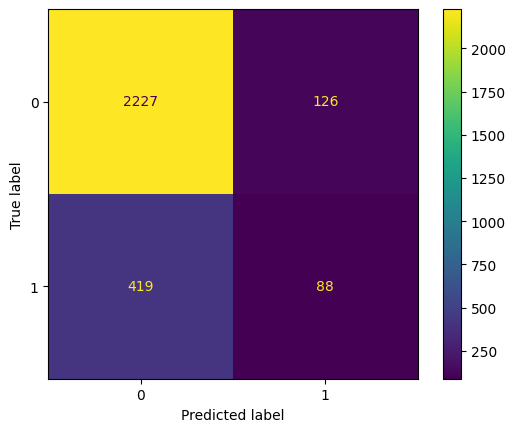

In [ ]:
# Generating array of values for confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)

# Plotting confusion matrix
metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()
plt.show()

Our model predicted three times as many false negatives than it did false positives, and it correctly identified only 16.6% of our users who actually churned.

### **Part 14. Feature importance**

Let's use our `plot_importance` function to inspect the most important features of our final model.

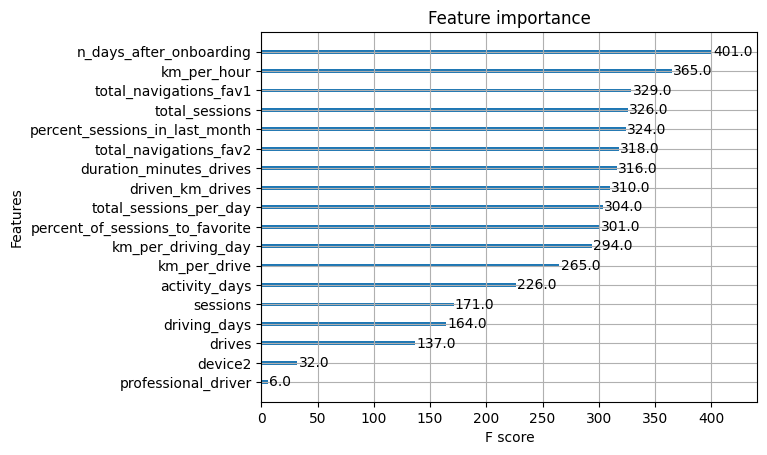

In [ ]:
plot_importance(model)
plt.show()

Our XGBoost model made more use of many of our features than did our logistic regression model, which weighted a single feature (`activity_days`) very heavily in its final prediction.

If anything, this underscores our focus on feature engineering. We notice that our engineered features accounted for six of our top 10 features (and three of our top five). Feature engineering is often one of the best and easiest ways for us to boost model performance.

Also, we note that our important features in one model might not be the same as our important features in another model. That's why we shouldn't discount features as unimportant without thoroughly examining them and understanding their relationship with our dependent variable, if possible. These discrepancies between features selected by models are typically caused by complex feature interactions.

We must remember, sometimes our data simply will not be predictive of our chosen target. This is common. Machine learning is a powerful tool, but it is not magic. If our data does not contain predictive signals, even the most complex algorithm will not be able to deliver consistent and accurate predictions. We shouldn't be afraid to draw this conclusion.

### **Part 15. Conclusion**

Now that we've built and tested our machine learning models, our next step is to share our findings with our Waze leadership team:

1. I wouldn't use the current model for churn prediction, because it yielded many false negative errors where he indicate users who will churn as retained.
2. The trade off is that the training data used to fit the model were small which resulted in low score.
3. Logistic regression is more simple, and the final results can be interpreted also it's more stable with small datasets. vice versa for tree based models.
4. Tree-based model are resistent to outliers and yield more accurate results for predicitions and can handle multicolinearity.
5. More data could be collected that need to balance the classes in the target variable to revel more about churn customer behavoir. Also more future engineering could be done to improve the model since it is one of the easiest and fastest ways to improve model performance.
6. To improve the model we need more features that reflect user churn behavior like their rates for the app, interactions with app notifications and user loyalty.